# Custom 6-Conv CNN Training
Trains the same `Custom6CNN` architecture used in the FYP `06-Custom_CNN_6conv_mRMR_SVM`
pipeline, wired to this dataset's `data/train|val|test/` split and `data/class_weights.json`
produced by `01_preprocessing.ipynb`.

Difference from the FYP reference notebook: that pipeline used a perfectly balanced
dataset (400/class) so it trained with a plain, unweighted loss. This dataset is
imbalanced (Tomato has a third of the others' images), so the loss here is
class-weighted (`CrossEntropyLoss(weight=class_weights_tensor)`).


In [1]:
import os, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

# ── Paths ──────────────────────────────────────
DATA_DIR   = Path("data")
OUTPUT_DIR = Path("cnn_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Hyperparameters ─────────────────────────────
CLASSES     = sorted(d.name for d in (DATA_DIR / "train").iterdir() if d.is_dir())
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 50
PATIENCE    = 5
MIN_EPOCHS_BEFORE_STOP = 15
LR          = 1e-3
SEED        = 42
NUM_WORKERS = 0
P_DROP      = 0.4

if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. Check nvidia-smi, then re-run.")

DEVICE = torch.device("cuda")
torch.backends.cudnn.benchmark = True
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

print(f"Classes ({NUM_CLASSES}): {CLASSES}")
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Classes (8): ['Apple', 'Berry', 'Fig', 'Guava', 'Orange', 'Palm', 'Persimmon', 'Tomato']
GPU : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.0 GB


## Data pipeline
Same `LeafDataset` / transforms as `01_preprocessing.ipynb`, reading directly from the physical `data/` split.

In [2]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=25, border_mode=0, fill=0, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.4),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0), p=0.5),
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


class LeafDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.transform = transform
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []
        for c in classes:
            for p in sorted(Path(root_dir, c).glob("*.jpg")):
                self.samples.append((str(p), self.class_to_idx[c]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = np.array(Image.open(path).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label


train_ds = LeafDataset(DATA_DIR / "train", CLASSES, transform=train_transform)
val_ds   = LeafDataset(DATA_DIR / "val",   CLASSES, transform=eval_transform)
test_ds  = LeafDataset(DATA_DIR / "test",  CLASSES, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

print(f"train: {len(train_ds)}  val: {len(val_ds)}  test: {len(test_ds)}")


train: 2510  val: 535  test: 543


## Class weights
Loaded from `data/class_weights.json` (computed on the train split only in `01_preprocessing.ipynb`).

In [3]:
with open(DATA_DIR / "class_weights.json") as f:
    class_weights = json.load(f)

class_weights_tensor = torch.tensor([class_weights[c] for c in CLASSES], dtype=torch.float32).to(DEVICE)
for c, w in class_weights.items():
    print(f"  {c:12s}: {w:.3f}")


  Apple       : 0.860
  Berry       : 1.313
  Fig         : 0.899
  Guava       : 0.857
  Orange      : 0.832
  Palm        : 0.957
  Persimmon   : 0.839
  Tomato      : 2.801


## Model: Custom 6-Conv CNN

Same architecture as `06-Custom_CNN_6conv_mRMR_SVM/06_Custom_CNN_6conv_mRMR_SVM.ipynb`:

```
Spatial flow (224x224 input):
  conv1 + pool -> 112
  conv2 + pool ->  56
  conv3 + pool ->  28
  conv4 + pool ->  14
  conv5 + pool ->   7
  conv6        ->   7  -> AdaptiveAvgPool(1,1)
Channel flow: 3 -> 32 -> 64 -> 128 -> 256 -> 512 -> 1024
FC: 1024 -> 1024 (1024-d embedding, reusable for mRMR+SVM later) -> num_classes
```


In [4]:
class Custom6CNN(nn.Module):
    def __init__(self, num_classes, p_drop=0.4):
        super().__init__()
        self.conv1 = nn.Conv2d(3,    32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32,   64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.pool          = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout       = nn.Dropout(p_drop)
        self.fc1           = nn.Linear(1024, 1024)       # 1024-d embedding
        self.fc2           = nn.Linear(1024, num_classes)

    def forward(self, x, return_embedding=False):
        x = self.pool(F.relu(self.conv1(x)))             # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))             # 112 ->  56
        x = self.pool(F.relu(self.conv3(x)))             #  56 ->  28
        x = self.pool(F.relu(self.conv4(x)))             #  28 ->  14
        x = self.pool(F.relu(self.conv5(x)))             #  14 ->   7
        x = F.relu(self.conv6(x))                        # keep 7x7 spatial map
        x   = self.adaptive_pool(x).view(x.size(0), -1)  # (B, 1024)
        emb = F.relu(self.fc1(x))                        # (B, 1024) embedding
        logits = self.fc2(self.dropout(emb))
        if return_embedding:
            return logits, emb
        return logits


model     = Custom6CNN(num_classes=NUM_CLASSES, p_drop=P_DROP).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)   # <- class-weighted, unlike the FYP reference
optimizer = optim.Adam(model.parameters(), lr=LR)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Custom6CNN — trainable parameters: {total_params:,}")


Custom6CNN — trainable parameters: 7,345,992


## Training (AMP + early stopping, best model saved on val loss)

In [5]:
BEST_MODEL_PATH = OUTPUT_DIR / "best_custom_6cnn_model.pth"

scaler_amp        = torch.amp.GradScaler("cuda")
best_val_loss     = float("inf")
epochs_no_improve = 0
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        with torch.no_grad():
            preds = outputs.argmax(1)

        run_loss    += loss.item() * inputs.size(0)
        run_correct += (preds == labels).sum().item()
        run_total   += inputs.size(0)

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda"):
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += inputs.size(0)

    val_loss /= val_total
    val_acc   = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"[Epoch {epoch:02d}]  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epoch < MIN_EPOCHS_BEFORE_STOP:
            print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE}, "
                  f"but continuing until at least epoch {MIN_EPOCHS_BEFORE_STOP}.")
        elif epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} after {epochs_no_improve} epochs without improvement.")
            break

print(f"\nTraining complete. Best model -> {BEST_MODEL_PATH}")


Epoch 1/50 [Train]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/17 [00:00<?, ?it/s]

[Epoch 01]  Train Acc: 0.2183  Val Acc: 0.2280  Train Loss: 1.7617  Val Loss: 1.5592
  -> Best model saved  (val_loss=1.5592)


Epoch 2/50 [Train]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/50 [Val]:   0%|          | 0/17 [00:00<?, ?it/s]

...

Epoch 29/50 [Val]:   0%|          | 0/17 [00:00<?, ?it/s]

[Epoch 29]  Train Acc: 0.9570  Val Acc: 0.9701  Train Loss: 0.1375  Val Loss: 0.1209


Epoch 30/50 [Train]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 30/50 [Val]:   0%|          | 0/17 [00:00<?, ?it/s]

[Epoch 30]  Train Acc: 0.9375  Val Acc: 0.9664  Train Loss: 0.1895  Val Loss: 0.0936
Early stopping at epoch 30 after 5 epochs without improvement.

Training complete. Best model -> cnn_results/best_custom_6cnn_model.pth


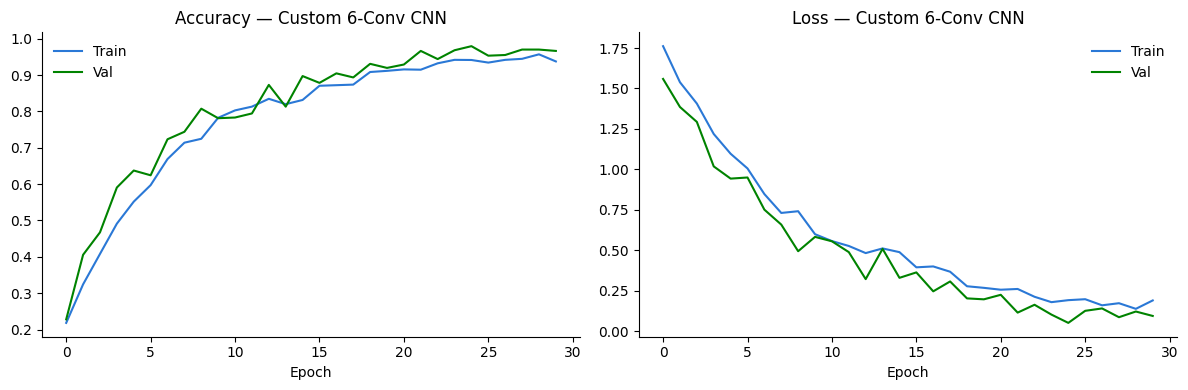

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_acc_hist, label="Train", color="#2a78d6")
axes[0].plot(val_acc_hist,   label="Val",   color="#008300")
axes[0].set_title("Accuracy — Custom 6-Conv CNN"); axes[0].set_xlabel("Epoch"); axes[0].legend(frameon=False)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(train_loss_hist, label="Train", color="#2a78d6")
axes[1].plot(val_loss_hist,   label="Val",   color="#008300")
axes[1].set_title("Loss — Custom 6-Conv CNN"); axes[1].set_xlabel("Epoch"); axes[1].legend(frameon=False)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()


## Test evaluation
Load the best (lowest val-loss) checkpoint and evaluate once, on the held-out test split.

In [7]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE)
        with torch.amp.autocast("cuda"):
            outputs = model(inputs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()
print(f"Test Accuracy (Custom 6-Conv CNN): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


Inference:   0%|          | 0/17 [00:00<?, ?it/s]

Test Accuracy (Custom 6-Conv CNN): 96.32%
Correct: 523 / 543


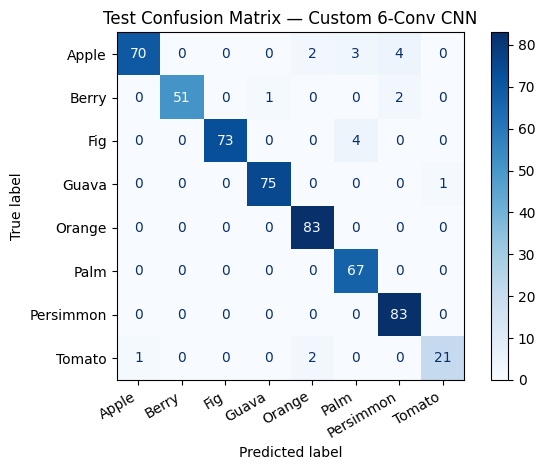

              precision    recall  f1-score   support

       Apple     0.9859    0.8861    0.9333        79
       Berry     1.0000    0.9444    0.9714        54
         Fig     1.0000    0.9481    0.9733        77
       Guava     0.9868    0.9868    0.9868        76
      Orange     0.9540    1.0000    0.9765        83
        Palm     0.9054    1.0000    0.9504        67
   Persimmon     0.9326    1.0000    0.9651        83
      Tomato     0.9545    0.8750    0.9130        24

    accuracy                         0.9632       543
   macro avg     0.9649    0.9551    0.9587       543
weighted avg     0.9651    0.9632    0.9629       543



In [8]:
cm   = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test Confusion Matrix — Custom 6-Conv CNN")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_cnn.png", dpi=150)
plt.show()

report_txt = classification_report(all_labels, all_preds, target_names=CLASSES, digits=4)
print(report_txt)
with open(OUTPUT_DIR / "classification_report_cnn.txt", "w") as f:
    f.write(report_txt)
pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASSES, output_dict=True, digits=4)
).transpose().to_csv(OUTPUT_DIR / "classification_report_cnn.csv")


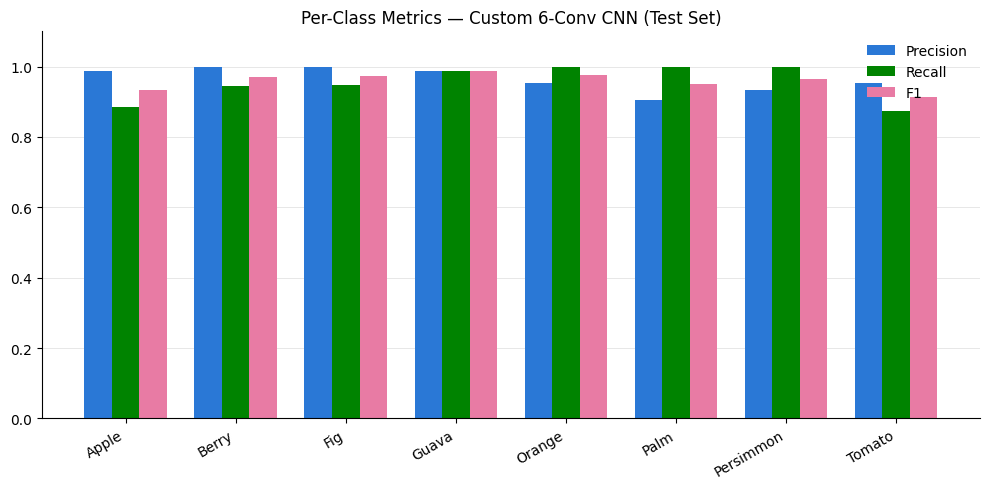

All artifacts saved in: /home/nathiskar/Documents/Task04/cnn_results
['best_custom_6cnn_model.pth', 'classification_report_cnn.csv', 'classification_report_cnn.txt', 'confusion_matrix_cnn.png', 'per_class_metrics_cnn.png', 'predictions_cnn.csv', 'training_curves.png']


In [9]:
precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
recall    = recall_score(all_labels,    all_preds, average=None, labels=range(NUM_CLASSES))
f1        = f1_score(all_labels,        all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, precision, w, label="Precision", color="#2a78d6")
ax.bar(x,     recall,    w, label="Recall",    color="#008300")
ax.bar(x + w, f1,        w, label="F1",        color="#e87ba4")
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("Per-Class Metrics — Custom 6-Conv CNN (Test Set)")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linewidth=0.5, color="#dddddd", zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_class_metrics_cnn.png", dpi=150)
plt.show()

pd.DataFrame({
    "Sample":     range(len(all_labels)),
    "True Label": [CLASSES[i] for i in all_labels],
    "Pred Label": [CLASSES[i] for i in all_preds],
    "Correct":    (all_preds == all_labels).astype(int)
}).to_csv(OUTPUT_DIR / "predictions_cnn.csv", index=False)

print("All artifacts saved in:", OUTPUT_DIR.resolve())
print(sorted(os.listdir(OUTPUT_DIR)))


## Feature / embedding extraction
1024-d penultimate-layer features (`return_embedding=True`), saved per split for a future mRMR + SVM / hybrid ML stage — same pattern as the FYP CNN6+mRMR+SVM pipeline.

In [10]:
@torch.no_grad()
def extract_embeddings(loader):
    model.eval()
    embs, labels = [], []
    for inputs, lbls in tqdm(loader, desc="Extracting embeddings", leave=False):
        inputs = inputs.to(DEVICE)
        with torch.amp.autocast("cuda"):
            _, emb = model(inputs, return_embedding=True)
        embs.append(emb.float().cpu().numpy())
        labels.append(lbls.numpy())
    return np.concatenate(embs), np.concatenate(labels)


# Deterministic (non-augmented) view of the train split, so features are stable/reproducible
# — unlike train_loader, which applies random augmentation for the training step above.
train_eval_ds      = LeafDataset(DATA_DIR / "train", CLASSES, transform=eval_transform)
train_embed_loader = DataLoader(train_eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, pin_memory=True)

train_embs, train_y = extract_embeddings(train_embed_loader)
val_embs,   val_y   = extract_embeddings(val_loader)
test_embs,  test_y  = extract_embeddings(test_loader)

np.save(OUTPUT_DIR / "train_embs.npy", train_embs)
np.save(OUTPUT_DIR / "val_embs.npy",   val_embs)
np.save(OUTPUT_DIR / "test_embs.npy",  test_embs)
np.save(OUTPUT_DIR / "train_y.npy",    train_y)
np.save(OUTPUT_DIR / "val_y.npy",      val_y)
np.save(OUTPUT_DIR / "test_y.npy",     test_y)

print(f"train_embs: {train_embs.shape}  val_embs: {val_embs.shape}  test_embs: {test_embs.shape}")
print(f"Saved to {OUTPUT_DIR.resolve()}")


Extracting embeddings:   0%|          | 0/79 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/17 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/17 [00:00<?, ?it/s]

train_embs: (2510, 1024)  val_embs: (535, 1024)  test_embs: (543, 1024)
Saved to /home/nathiskar/Documents/Task04/cnn_results


## Summary

- `cnn_results/best_custom_6cnn_model.pth` — best checkpoint (lowest val loss)
- `cnn_results/training_curves.png` — train/val accuracy & loss over epochs
- `cnn_results/confusion_matrix_cnn.png`, `classification_report_cnn.{txt,csv}`, `per_class_metrics_cnn.png`, `predictions_cnn.csv` — test-set evaluation

**Next step** (matching the FYP hybrid pipeline): extract 1024-d embeddings via `model(x, return_embedding=True)`, run mRMR feature selection, and train an SVM on the selected features — same pattern as `06_Custom_CNN_6conv_mRMR_SVM.ipynb`.

- `train_embs.npy` / `val_embs.npy` / `test_embs.npy` (+ matching `*_y.npy` labels) — 1024-d penultimate-layer features per split, for a future mRMR + SVM / hybrid ML stage